# San Luis Valley aeromagnetic levelling

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import cmocean
import geopandas as gpd
import harmonica as hm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

## Load data

In [2]:
data_df = pd.read_csv("data/san_luis_magnetics.csv")

# # every x points
# data_df = data_df[::10]

# # every x line
# data_df = data_df[
#     data_df.line.isin(data_df.line.unique()[data_df.line.unique() % 8 == 0])
# ]

# define survey lines (0) vs tie lines (1)
data_df["line_type"] = np.where(data_df.line_type == "line", 0, 1)

# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry
0,1,0,37.5256,-105.6335,443997.28,4153366.29,1.099466e+09,2488.22,-837.13,-841.75,POINT (443997.28 4153366.29)
1,1,0,37.5256,-105.6338,443974.30,4153366.44,1.099466e+09,2488.37,-837.06,-841.68,POINT (443974.3 4153366.44)
2,1,0,37.5256,-105.6341,443951.32,4153365.49,1.099466e+09,2488.51,-837.00,-841.62,POINT (443951.32 4153365.49)
3,1,0,37.5256,-105.6343,443927.47,4153365.65,1.099466e+09,2488.66,-836.92,-841.54,POINT (443927.47 4153365.65)
4,1,0,37.5256,-105.6346,443904.49,4153365.80,1.099466e+09,2488.80,-836.87,-841.49,POINT (443904.49 4153365.8)


In [3]:
data_df.describe()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa
count,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06
mean,3.201125e+02,1.701555e-01,3.706693e+01,-1.058167e+02,4.274058e+05,4.102621e+06,1.100047e+09,2.536180e+03,-5.682331e+02,-5.682027e+02
std,1.977824e+02,3.757695e-01,2.912172e-01,1.592203e-01,1.410116e+04,3.232789e+04,2.658211e+06,1.042036e+02,2.246053e+02,2.223726e+02
min,1.000000e+00,0.000000e+00,3.644480e+01,-1.061741e+02,3.960613e+05,4.033616e+06,1.039259e+09,2.250880e+03,-2.336730e+03,-2.334330e+03
25%,1.450000e+02,0.000000e+00,3.684740e+01,-1.059410e+02,4.162816e+05,4.078258e+06,1.099473e+09,2.472980e+03,-7.018800e+02,-7.003200e+02
50%,2.990000e+02,0.000000e+00,3.710280e+01,-1.058133e+02,4.275882e+05,4.106630e+06,1.099639e+09,2.506760e+03,-5.773700e+02,-5.767200e+02
75%,4.980000e+02,0.000000e+00,3.731080e+01,-1.056870e+02,4.388134e+05,4.129647e+06,1.100764e+09,2.578120e+03,-4.536800e+02,-4.550900e+02
max,6.500000e+02,1.000000e+00,3.755870e+01,-1.054484e+02,4.602512e+05,4.157199e+06,1.102070e+09,3.136350e+03,2.083250e+03,1.973760e+03


In [4]:
airbornegeo.median_line_spacing(
    data_df[data_df.line_type == 0][::20],  # every 20th point to speed up
    line_column="line",
)

np.float64(215.31550826626304)

In [5]:
airbornegeo.median_line_spacing(
    data_df[data_df.line_type == 1][::20],  # every 20th point to speed up
    line_column="line",
)

np.float64(1007.0896027699907)

In [6]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df, groupby_column="line"
)
data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry,distance_along_line
0,1,0,37.5256,-105.6335,443997.28,4153366.29,1.099466e+09,2488.22,-837.13,-841.75,POINT (443997.28 4153366.29),0.000000
1,1,0,37.5256,-105.6338,443974.30,4153366.44,1.099466e+09,2488.37,-837.06,-841.68,POINT (443974.3 4153366.44),22.980490
2,1,0,37.5256,-105.6341,443951.32,4153365.49,1.099466e+09,2488.51,-837.00,-841.62,POINT (443951.32 4153365.49),45.980118
3,1,0,37.5256,-105.6343,443927.47,4153365.65,1.099466e+09,2488.66,-836.92,-841.54,POINT (443927.47 4153365.65),69.830654
4,1,0,37.5256,-105.6346,443904.49,4153365.80,1.099466e+09,2488.80,-836.87,-841.49,POINT (443904.49 4153365.8),92.811144


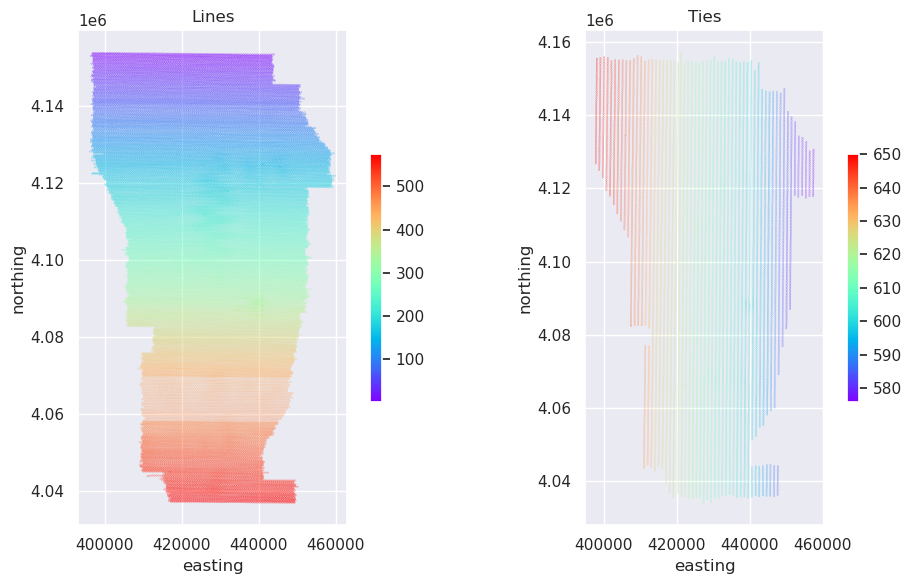

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))


df = data_df[::20]

ax = df[df.line_type == 0].plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[0],
    colorbar=False,
    title="Lines",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = df[df.line_type == 1].plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[1],
    colorbar=False,
    title="Ties",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

# Cross-over levelling

## Find intersections

In [8]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="pairs",
)
inters

Line pairs:   0%|          | 0/43050 [00:00<?, ?it/s]

INFO:airbornegeo:found 24088 intersections


,line1,line2,geometry,max_dist,easting,northing
0,1,598,POINT (442412 4153348),10.811184,442412.0,4153348.0
1,1,601,POINT (440387 4153346),5.637987,440387.0,4153346.0
2,1,602,POINT (439384 4153349),8.643726,439384.0,4153349.0
3,1,603,POINT (438323 4153354),9.194265,438323.0,4153354.0
4,1,604,POINT (437372 4153360),9.232622,437372.0,4153360.0
...,...,...,...,...,...,...
24083,575,618,POINT (422286 4037194),4.832029,422286.0,4037194.0
24084,575,619,POINT (421307 4037194),11.500039,421307.0,4037194.0
24085,575,622,POINT (420268 4037193),4.083969,420268.0,4037193.0
24086,575,623,POINT (419038 4037192),5.882457,419038.0,4037192.0


## Add intersections as rows to the dataframe

In [9]:
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    line_column="line",
    to_interp="unlevelled_tfa",
    interp_on="distance_along_line",
    window_width=500,
    method="cubic",
    extrapolate=True,
)

Interpolating segments:   0%|          | 0/649 [00:00<?, ?it/s]

In [10]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters, line_column="line")

[]

## Calculate initial cross-over errors

In [11]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    line_column="line",
)
inters.head()

,line1,line2,geometry,max_dist,easting,northing,dist_along_line1,dist_along_line2,line1_interpolation_type,line2_interpolation_type,mistie_0
0,1,598,POINT (442412 4153348),10.811184,442412.0,4153348.0,1585.815567,101406.261097,interpolated,interpolated,13.107907
1,1,601,POINT (440387 4153346),5.637987,440387.0,4153346.0,3611.147631,118349.152210,interpolated,interpolated,-2.060109
2,1,602,POINT (439384 4153349),8.643726,439384.0,4153349.0,4614.249436,117700.089264,interpolated,interpolated,-1.611797
3,1,603,POINT (438323 4153354),9.194265,438323.0,4153354.0,5675.316172,1553.779643,interpolated,interpolated,-9.936734
4,1,604,POINT (437372 4153360),9.232622,437372.0,4153360.0,6626.480517,118349.910213,interpolated,interpolated,-3.030689


In [12]:
airbornegeo.plotly_points(
    inters,
    color_col="mistie_0",
    hover_cols=["line1", "line2"],
    robust=True,
    absolute=True,
    cmap="balance",
    size=3,
    edge_width=0,
)

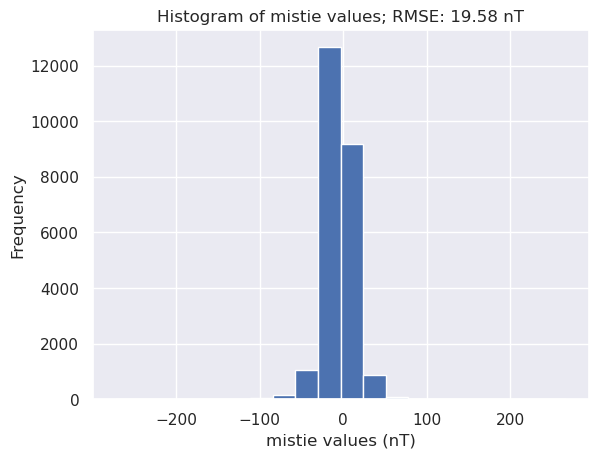

In [13]:
ax = inters[inters.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters[inters.columns[-1]]), 2)} nT"
);

  0%|          | 0/10 [00:00<?, ?it/s]

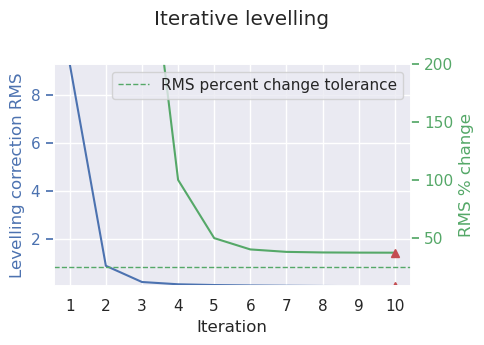

Levelling terminated after 10 iterations with RMS of levelling correction of 0.01 because maximum number of iterations (10) reached.


,line1,line2,geometry,max_dist,easting,northing,dist_along_line1,dist_along_line2,line1_interpolation_type,line2_interpolation_type,...,mistie_11,mistie_12,mistie_13,mistie_14,mistie_15,mistie_16,mistie_17,mistie_18,mistie_19,mistie_20
0,1,598,POINT (442412 4153348),10.811184,442412.0,4153348.0,1585.815567,101406.261097,interpolated,interpolated,...,-0.381852,-0.348596,-0.374276,-0.350848,-0.370379,-0.353582,-0.368261,-0.356160,-0.367069,-0.358352
1,1,601,POINT (440387 4153346),5.637987,440387.0,4153346.0,3611.147631,118349.152210,interpolated,interpolated,...,1.967864,1.960152,1.937533,1.932387,1.915189,1.911670,1.898748,1.896271,1.886671,1.884880
2,1,602,POINT (439384 4153349),8.643726,439384.0,4153349.0,4614.249436,117700.089264,interpolated,interpolated,...,0.108818,0.102733,0.081630,0.077650,0.061608,0.058928,0.046876,0.045006,0.036053,0.034703
3,1,603,POINT (438323 4153354),9.194265,438323.0,4153354.0,5675.316172,1553.779643,interpolated,interpolated,...,-1.035895,-1.040329,-1.059829,-1.062629,-1.077448,-1.079280,-1.090412,-1.091669,-1.099936,-1.100841
4,1,604,POINT (437372 4153360),9.232622,437372.0,4153360.0,6626.480517,118349.910213,interpolated,interpolated,...,-1.131223,-1.134037,-1.152099,-1.153741,-1.167465,-1.168465,-1.178772,-1.179427,-1.187079,-1.187547


In [15]:
data_df, inters_alternating_iterative = (
    airbornegeo.alternating_iterative_line_levelling(
        data_df,
        inters,
        data_col="unlevelled_tfa",
        levelled_col="mag_levelled_alternating_trend1",
        line_column="line",
        distance_column="distance_along_line",
        degree=1,
        max_iterations=10,
        rms_percent_change_tolerance=25,
        plot_dynamic_convergence=True,
    )
)
inters_alternating_iterative.head()

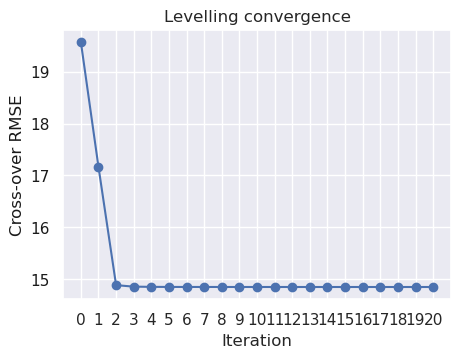

In [16]:
airbornegeo.plot_levelling_convergence(inters_alternating_iterative)

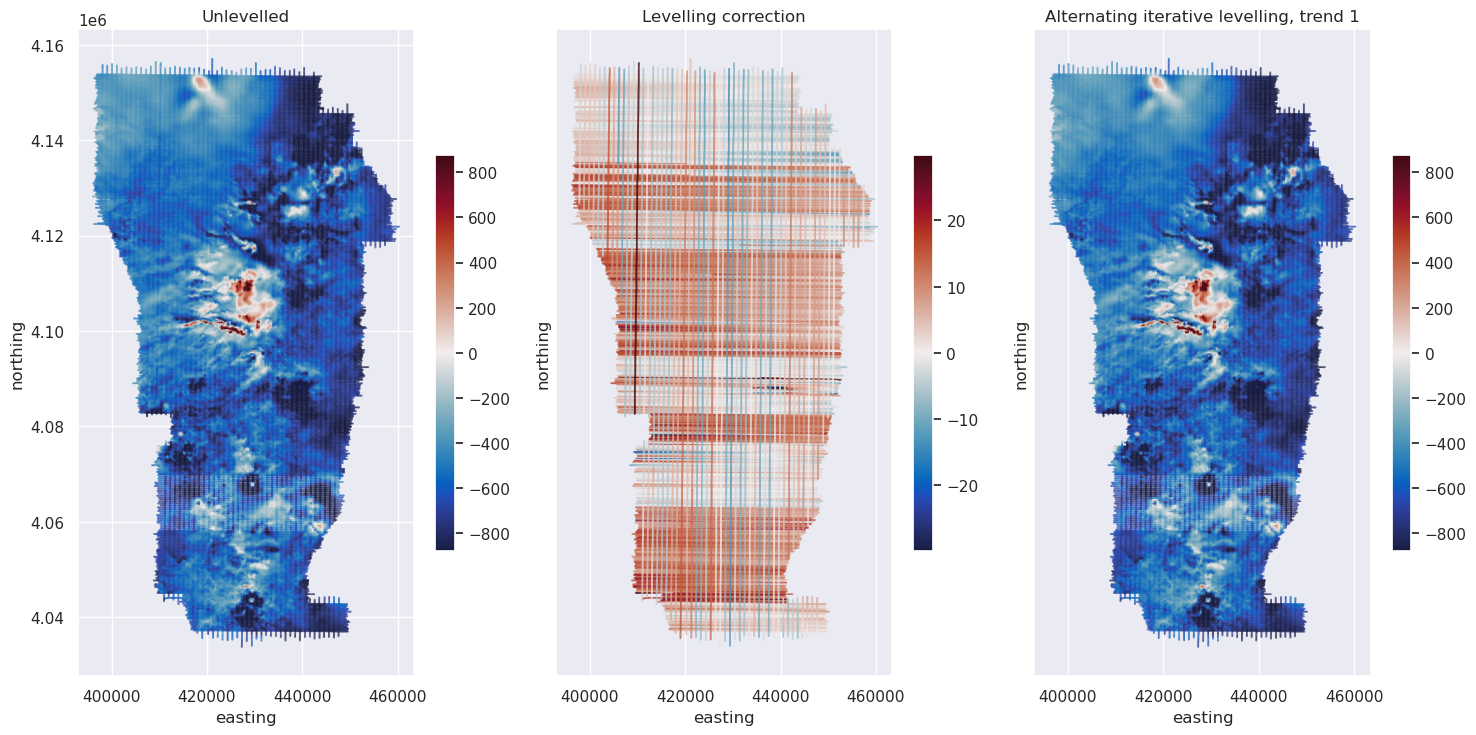

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = (
    data_df.mag_levelled_alternating_trend1 - data_df.unlevelled_tfa
)
df = data_df[::10]

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=99.5)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="mag_levelled_alternating_trend1",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Alternating iterative levelling, trend 1",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

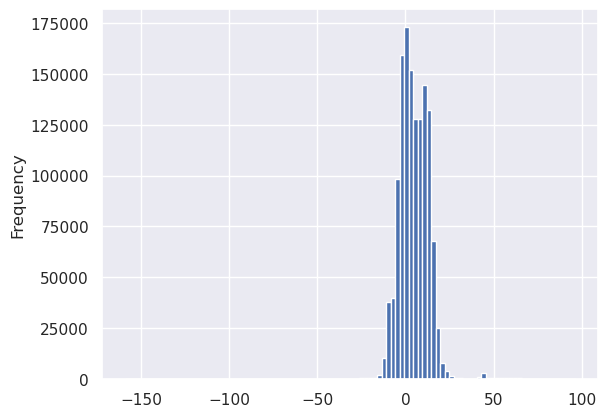

In [18]:
data_df.levelling_correction.plot.hist(bins=100)

In [19]:
data_df.groupby("line").levelling_correction.mean().sort_values()

line
340   -64.920950
343   -34.627047
641   -12.602359
352   -12.141454
611   -11.449410
         ...    
536    23.436270
542    26.863932
346    36.064890
637    43.147474
330    54.446484
Name: levelling_correction, Length: 649, dtype: float64

In [20]:
airbornegeo.plot_line_and_crosses(
    data_df,
    line=343,
    x="distance_along_line",
    y=["unlevelled_tfa", "mag_levelled_alternating_trend1"],
    y_axes=[1, 1],
    plot_inters=[False, False],
    line_column="line",
)

In [21]:
# save to csv
data_df.to_csv("data/san_luis_magnetics_crossover_levelled.csv", index=False)

In [2]:
levelled_df = pd.read_csv("data/san_luis_magnetics_crossover_levelled.csv")

levelled_df = levelled_df[levelled_df.is_intersection == False]
levelled_df = levelled_df.drop(
    columns=[
        "is_intersection",
        "intersecting_line",
        "unlevelled_tfa_interpolation_type",
    ]
)
levelled_df

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry,distance_along_line,mag_levelled_alternating_trend1,levelling_correction
0,1,0.0,37.5256,-105.6335,443997.28,4153366.29,1.099466e+09,2488.22,-837.13,-841.75,POINT (443997.28 4153366.29),0.000000,-839.553441,-2.423441
1,1,0.0,37.5256,-105.6338,443974.30,4153366.44,1.099466e+09,2488.37,-837.06,-841.68,POINT (443974.3 4153366.44),22.980490,-839.481347,-2.421347
2,1,0.0,37.5256,-105.6341,443951.32,4153365.49,1.099466e+09,2488.51,-837.00,-841.62,POINT (443951.32 4153365.49),45.980118,-839.419251,-2.419251
3,1,0.0,37.5256,-105.6343,443927.47,4153365.65,1.099466e+09,2488.66,-836.92,-841.54,POINT (443927.47 4153365.65),69.830654,-839.337078,-2.417078
4,1,0.0,37.5256,-105.6346,443904.49,4153365.80,1.099466e+09,2488.80,-836.87,-841.49,POINT (443904.49 4153365.8),92.811144,-839.284984,-2.414984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319461,650,1.0,37.2819,-106.1526,397822.43,4126738.17,1.099469e+09,2575.13,-414.45,-428.37,POINT (397822.43 4126738.17),29117.045891,-416.167680,-1.717680
1319462,650,1.0,37.2816,-106.1526,397822.13,4126713.76,1.099469e+09,2574.66,-413.57,-427.49,POINT (397822.13 4126713.76),29141.457735,-415.286106,-1.716106
1319463,650,1.0,37.2814,-106.1526,397820.96,4126690.47,1.099469e+09,2574.23,-412.73,-426.66,POINT (397820.96 4126690.47),29164.777104,-414.444603,-1.714603
1319464,650,1.0,37.2812,-106.1526,397820.66,4126666.07,1.099469e+09,2573.80,-411.87,-425.80,POINT (397820.66 4126666.07),29189.178948,-413.583030,-1.713030


## Assessing levelling errors

In [7]:
# block reduce the line data
levelled_df = airbornegeo.block_reduce(
    levelled_df,
    np.median,
    spacing=500,
    # reduce_by=('easting', 'northing'),
    reduce_by="distance_along_line",
    groupby_column="line",
)
levelled_df = levelled_df.dropna(
    subset=["easting", "northing", "height", "unlevelled_tfa"]
)
levelled_df

Block-reducing segments:   0%|          | 0/649 [00:00<?, ?it/s]

,distance_along_line,tmp,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,mag_levelled_alternating_trend1,levelling_correction
0,242.202999,0.0,1,0.0,37.52550,-105.63625,443755.150,4153363.960,1.099466e+09,2489.920,-836.780,-841.380,-839.183465,-2.401370
1,748.743819,0.0,1,0.0,37.52545,-105.64200,443248.785,4153358.055,1.099466e+09,2489.705,-837.305,-841.865,-839.653928,-2.355212
2,1256.177706,0.0,1,0.0,37.52540,-105.64775,442741.535,4153351.390,1.099466e+09,2484.810,-836.955,-841.450,-839.263972,-2.308972
3,1765.351097,0.0,1,0.0,37.52530,-105.65350,442232.525,4153346.520,1.099466e+09,2481.435,-836.375,-840.730,-838.639668,-2.262573
4,2263.870087,0.0,1,0.0,37.52520,-105.65910,441734.130,4153343.550,1.099466e+09,2477.690,-836.700,-840.880,-838.917146,-2.217146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60765,26940.990139,0.0,650,1.0,37.30150,-106.15260,397850.700,4128913.810,1.099469e+09,2600.020,-502.400,-508.450,-504.257953,-1.857953
60766,27441.460867,0.0,650,1.0,37.29690,-106.15260,397848.170,4128413.400,1.099469e+09,2594.310,-467.970,-479.400,-469.795692,-1.825692
60767,27955.251045,0.0,650,1.0,37.29230,-106.15260,397841.905,4127899.715,1.099469e+09,2588.835,-447.865,-463.670,-449.657572,-1.792572
60768,28470.101452,0.0,650,1.0,37.28770,-106.15260,397834.740,4127384.930,1.099469e+09,2583.350,-479.410,-485.740,-481.178681,-1.759383


In [8]:
# save to csv
levelled_df.to_csv(
    "data/san_luis_magnetics_crossover_levelled_blocked.csv", index=False
)

In [3]:
levelled_df = pd.read_csv("data/san_luis_magnetics_crossover_levelled_blocked.csv")
levelled_df

,distance_along_line,tmp,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,mag_levelled_alternating_trend1,levelling_correction
0,242.202999,0.0,1,0.0,37.52550,-105.63625,443755.150,4153363.960,1.099466e+09,2489.920,-836.780,-841.380,-839.183465,-2.401370
1,748.743819,0.0,1,0.0,37.52545,-105.64200,443248.785,4153358.055,1.099466e+09,2489.705,-837.305,-841.865,-839.653928,-2.355212
2,1256.177706,0.0,1,0.0,37.52540,-105.64775,442741.535,4153351.390,1.099466e+09,2484.810,-836.955,-841.450,-839.263972,-2.308972
3,1765.351097,0.0,1,0.0,37.52530,-105.65350,442232.525,4153346.520,1.099466e+09,2481.435,-836.375,-840.730,-838.639668,-2.262573
4,2263.870087,0.0,1,0.0,37.52520,-105.65910,441734.130,4153343.550,1.099466e+09,2477.690,-836.700,-840.880,-838.917146,-2.217146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60765,26940.990139,0.0,650,1.0,37.30150,-106.15260,397850.700,4128913.810,1.099469e+09,2600.020,-502.400,-508.450,-504.257953,-1.857953
60766,27441.460867,0.0,650,1.0,37.29690,-106.15260,397848.170,4128413.400,1.099469e+09,2594.310,-467.970,-479.400,-469.795692,-1.825692
60767,27955.251045,0.0,650,1.0,37.29230,-106.15260,397841.905,4127899.715,1.099469e+09,2588.835,-447.865,-463.670,-449.657572,-1.792572
60768,28470.101452,0.0,650,1.0,37.28770,-106.15260,397834.740,4127384.930,1.099469e+09,2583.350,-479.410,-485.740,-481.178681,-1.759383


In [4]:
coords = (
    levelled_df.easting,
    levelled_df.northing,
    levelled_df.height,
)

In [5]:
eqs_kwargs = dict(  # noqa: C408
    damping=0.01,
    depth="default",
    block_size=500,
)

# eqs = hm.EquivalentSourcesGB(
#     window_size=40e3,
#     random_state=42,
#     **eqs_kwargs,
# )

eqs = hm.EquivalentSources(**eqs_kwargs)

bytes = eqs.estimate_required_memory(coords)
print(f"{bytes / 1e9} GB ram required")

10.41403336 GB ram required


In [6]:
eqs.fit(coords, levelled_df.unlevelled_tfa.to_numpy())

,damping,0.01
,points,None
,depth,'default'
,block_size,500
,parallel,True
,dtype,'float64'


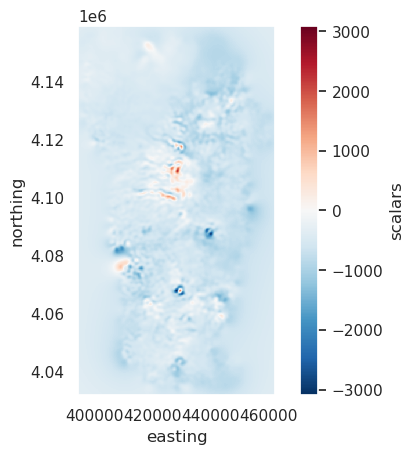

In [7]:
# Define grid coordinates
grid_coords = vd.grid_coordinates(
    region=vd.pad_region(vd.get_region(coords), 2e3),
    spacing=200,
    extra_coords=levelled_df.height.mean(),  # upward continue
    adjust="region",
)
grid_unlevelled = eqs.grid(grid_coords)

# grid_unlevelled = vd.distance_mask(
#     (coords[0], coords[1]), maxdist=2e3, grid=grid_unlevelled
# )
grid_unlevelled = grid_unlevelled.reset_coords(names="upward").scalars

grid_unlevelled.plot().axes.set_aspect("equal")

In [8]:
eqs.fit(coords, levelled_df.mag_levelled_alternating_trend1)

,damping,0.01
,points,None
,depth,'default'
,block_size,500
,parallel,True
,dtype,'float64'


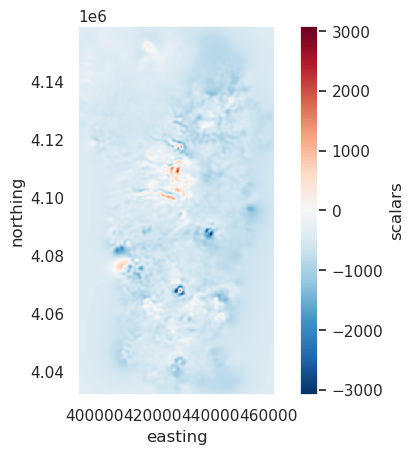

In [9]:
grid_levelled = eqs.grid(grid_coords)
grid_levelled = grid_levelled.reset_coords(names="upward").scalars
grid_levelled.plot().axes.set_aspect("equal")

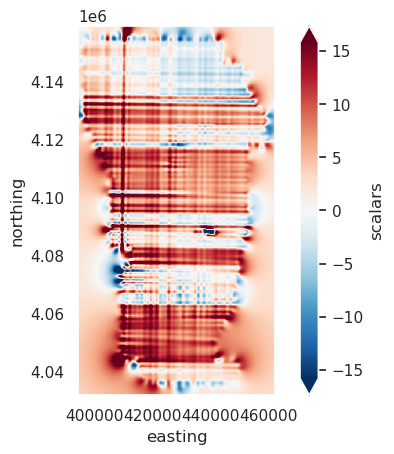

In [32]:
(grid_levelled - grid_unlevelled).plot(robust=True).axes.set_aspect("equal")

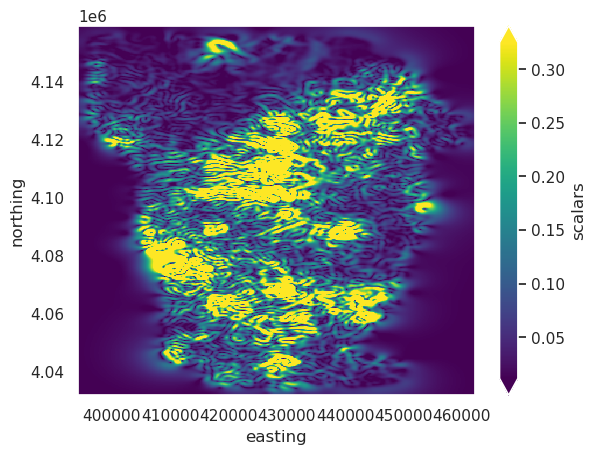

In [30]:
hg_unlevelled = airbornegeo.filter_grid(
    grid_unlevelled, filter_type="horizontal_gradient"
)
vmin, vmax = vd.minmax(
    hg_unlevelled,
    min_percentile=8,
    max_percentile=92,
)
hg_unlevelled.plot(
    # robust=True,
    vmin=vmin,
    vmax=vmax,
)

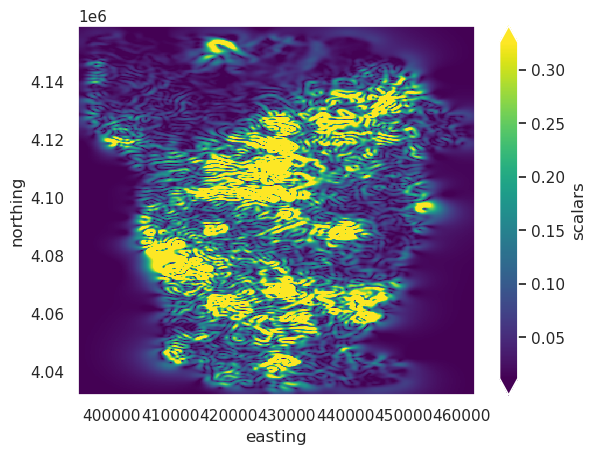

In [31]:
hg_levelled = airbornegeo.filter_grid(grid_levelled, filter_type="horizontal_gradient")
vmin, vmax = vd.minmax(
    hg_levelled,
    min_percentile=8,
    max_percentile=92,
)
hg_levelled.plot(
    # robust=True,
    vmin=vmin,
    vmax=vmax,
)

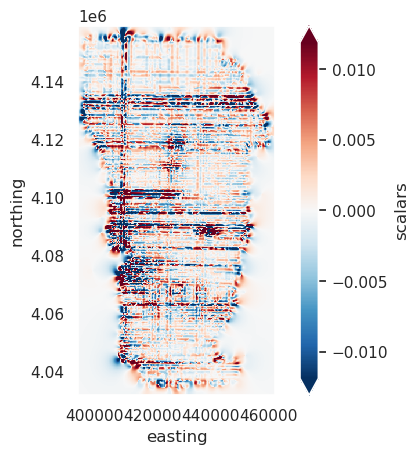

In [29]:
(hg_levelled - hg_unlevelled).plot(robust=True).axes.set_aspect("equal")

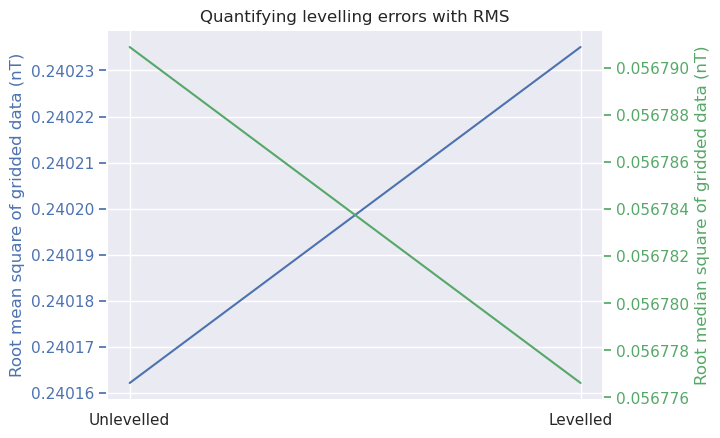

In [14]:
fig, ax = plt.subplots(1, 1, sharex=True)
ax.plot(
    ["Unlevelled", "Levelled"],
    [airbornegeo.rmse(hg_unlevelled), airbornegeo.rmse(hg_levelled)],
    c="b",
)
ax.set_ylabel("Root mean square of gridded data (nT)", color="b")
ax.tick_params(axis="y", colors="b", which="both")

ax2 = ax.twinx()
ax2.plot(
    ["Unlevelled", "Levelled"],
    [
        airbornegeo.rmse(hg_unlevelled, as_median=True),
        airbornegeo.rmse(hg_levelled, as_median=True),
    ],
    c="g",
)
ax2.grid(visible=False)
ax2.set_ylabel("Root median square of gridded data (nT)", color="g")
ax2.tick_params(axis="y", colors="g", which="both")

plt.title("Quantifying levelling errors with RMS");

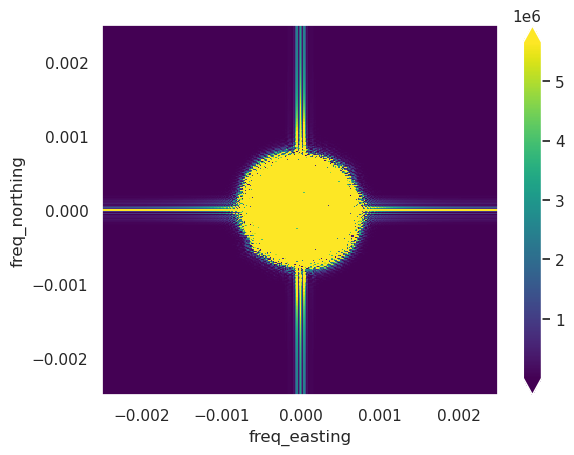

In [27]:
import xrft

powerspec_unlevelled = xrft.power_spectrum(grid_unlevelled)
vmin, vmax = vd.minmax(
    powerspec_unlevelled,
    min_percentile=8,
    max_percentile=92,
)
powerspec_unlevelled.plot(
    vmin=vmin,
    vmax=vmax,
)

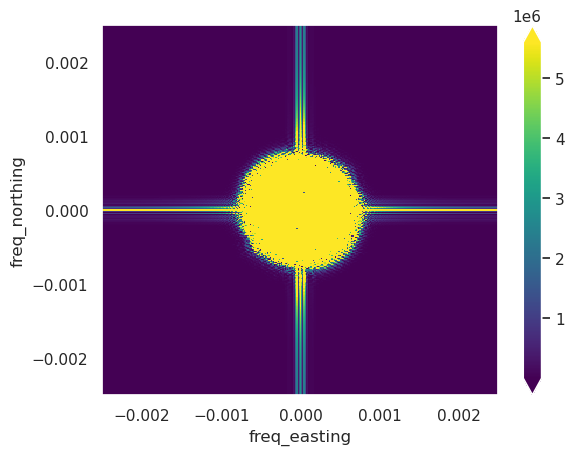

In [28]:
powerspec_levelled = xrft.power_spectrum(grid_levelled)
vmin, vmax = vd.minmax(
    powerspec_levelled,
    min_percentile=8,
    max_percentile=92,
)
powerspec_levelled.plot(
    vmin=vmin,
    vmax=vmax,
)

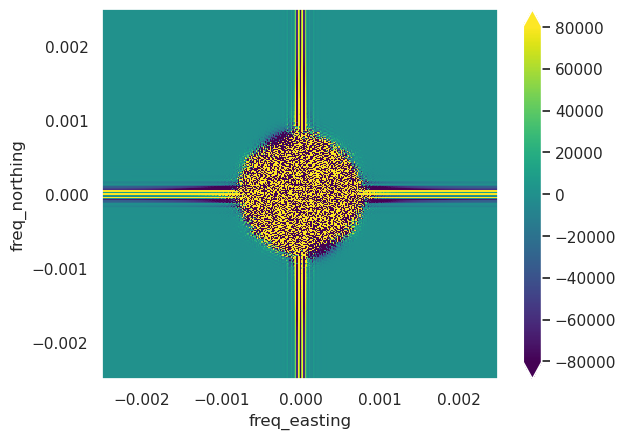

In [24]:
dif = powerspec_levelled - powerspec_unlevelled
maxabs = vd.maxabs(
    dif,
    percentile=90,
)
dif.plot(
    vmin=-maxabs,
    vmax=maxabs,
)